# Praktikum dan Tugas Data Preprocessing
### 4233201 – Kecerdasan Buatan | Semester Genap TA 2026/2027
### Week/Sesi: 2/3 | Nama: Tika Altiora Sitanggang | NIM: 42324025
## 1. Missing Value
### 1.1 Import Library dan Load Dataset

In [3]:
import pandas as pd

path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


### 1.2 Mengecek Missing Value
Menghitung jumlah dan persentase data yang hilang (NaN) di setiap kolom
untuk memahami kualitas dataset.

In [4]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

### 1.3 Menghapus Baris/Kolom dengan `dropna()`
`df.dropna()` digunakan untuk menghapus baris atau kolom yang memiliki missing value.

In [5]:
# Menghapus baris yang mengandung NaN
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [6]:
# Menghapus kolom yang mengandung NaN
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


In [7]:
# thresh=5 -> hanya baris dengan minimal 5 nilai valid yang dipertahankan
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


In [8]:
# Hanya menghapus baris yang NaN pada kolom 'Age'
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


In [9]:
# Menghapus kolom 'Blood Type' karena missing value terlalu banyak (60%)
df_drop = df.drop(columns='Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


### 1.4 Imputasi Missing Value dengan `fillna()`
`fillna()` digunakan untuk mengisi nilai kosong menggunakan metode statistik
seperti mean, median, atau mode.
- Kolom **Age** diisi dengan **mean**
- Kolom **Shoe Chart** diisi dengan **median**
- Kolom **Fav Fruit** diisi dengan **mode**

In [10]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [11]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [12]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


### 1.5 Backward Fill & Forward Fill
Missing value juga bisa diisi dengan **backward fill** (nilai setelahnya) dan
**forward fill** (nilai sebelumnya).

In [13]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [14]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


## 2. Outliers
### 2.1 Load Dataset dan Deteksi Outlier secara Visual
Mendeteksi outlier menggunakan boxplot dari seaborn. Outlier berada di luar
titik *whiskers* pada boxplot.

In [15]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: ylabel='Height'>

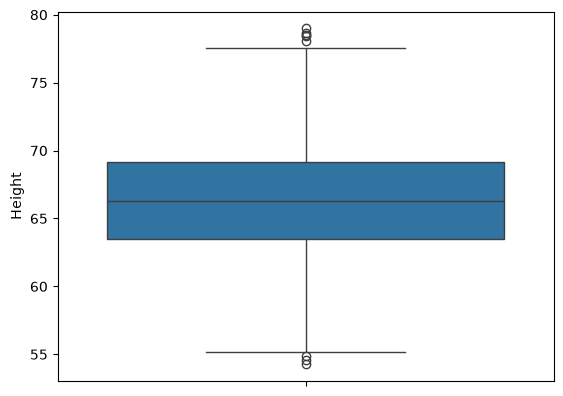

In [16]:
import seaborn as sns
sns.boxplot(df2['Height'])

### 2.2 Menghapus Outlier dengan IQR

<Axes: ylabel='Height'>

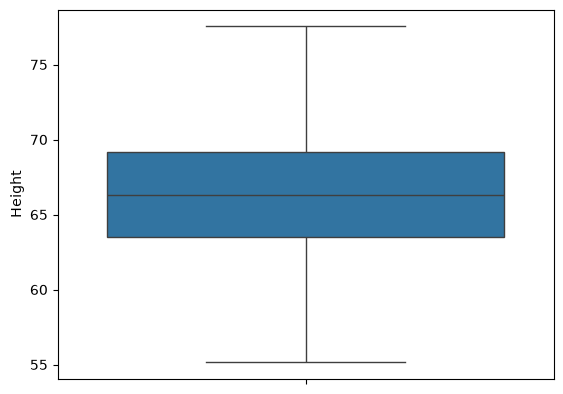

In [17]:
import numpy as np

# Identifikasi Q1 dan Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bound
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outlier
clean_data = df2[(df2['Height'] >= lower_bound) & (df2['Height'] <= upper_bound)]

sns.boxplot(clean_data['Height'])

<Axes: ylabel='Weight'>

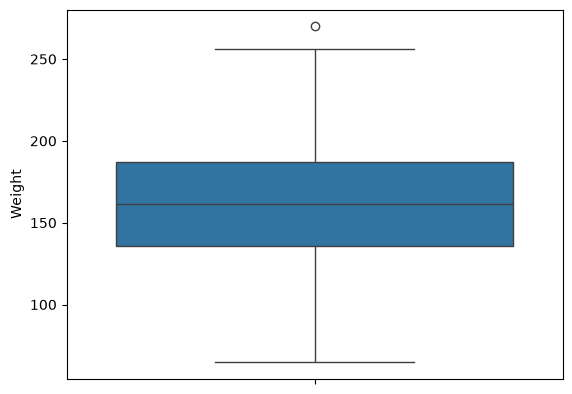

In [18]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

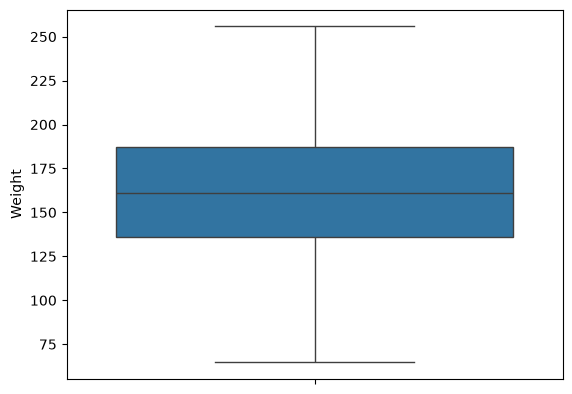

In [19]:
q1, q3 = np.percentile(df2['Weight'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
clean_data = df2[(df2['Weight'] >= lower_bound) & (df2['Weight'] <= upper_bound)]

sns.boxplot(clean_data['Weight'])

### 2.3 Deteksi dengan Matplotlib dan Fungsi Otomatis

C:\Users\tikas\AppData\Local\Temp\ipykernel_13372\1973051569.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\tikas\AppData\Local\Temp\ipykernel_13372\1973051569.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


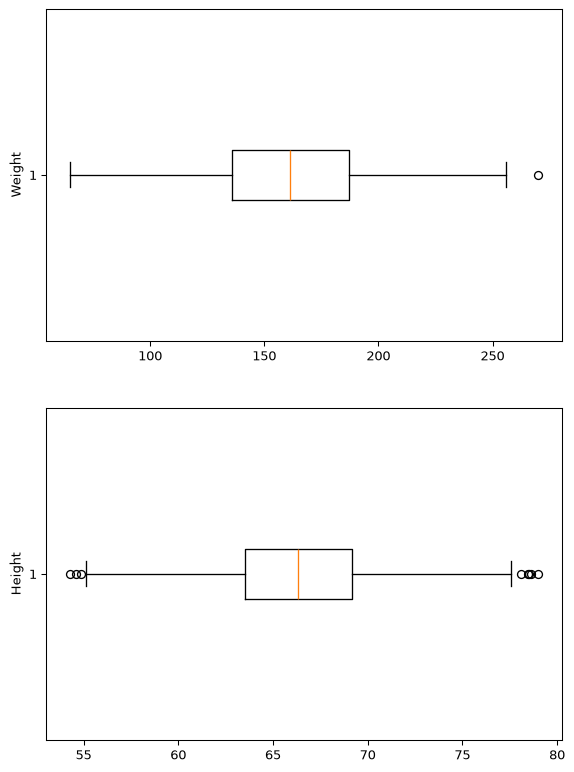

In [20]:
import matplotlib.pyplot as plt

columns_to_plot = ['Weight', 'Height']
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:
    axs = [axs]
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)
plt.show()

C:\Users\tikas\AppData\Local\Temp\ipykernel_17424\978350297.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\tikas\AppData\Local\Temp\ipykernel_17424\978350297.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


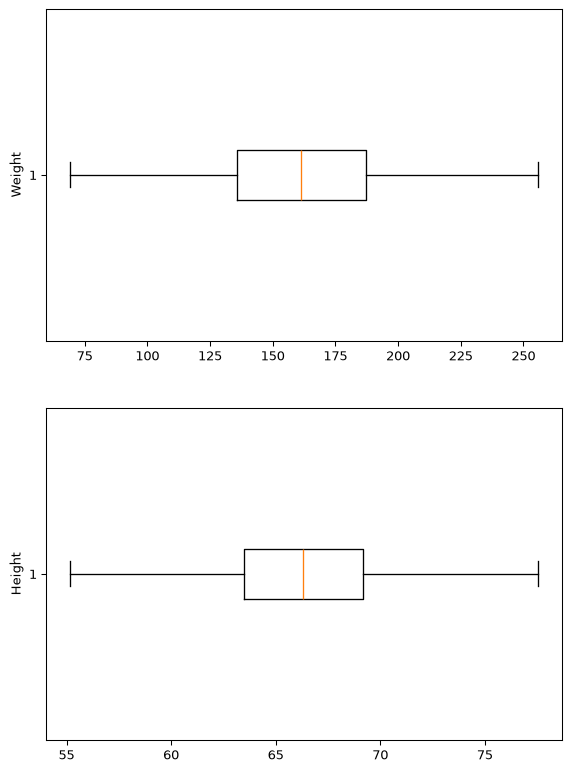

In [22]:
def remove_outliers_sequentially(data, columns):
    df_cleaned = data.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])

columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:
    axs = [axs]
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)
plt.show()

### 2.4 Rescaling dengan MinMaxScaler

In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

numeric_cols = clean_data.select_dtypes(include=[np.number]).columns
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns

rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data.index)

final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)
final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


## 3. Tugas — Handling Missing Value pada Titanic-Dataset.csv
Dataset Titanic memiliki missing value pada kolom **Age**, **Cabin**, dan **Embarked**.
Strategi penanganan yang digunakan:
- **Cabin** → dihapus (persentase missing terlalu tinggi, >75%)
- **Age** → diisi dengan **median** (lebih tahan terhadap outlier dibanding mean)
- **Embarked** → diisi dengan **mode** (nilai kategori yang paling sering muncul)

In [24]:
titanic = pd.read_csv("Titanic-Dataset.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
# 3.1 Cek jumlah dan persentase missing value awal
print("Jumlah missing value:")
print(titanic.isnull().sum())

print("\nPersentase missing value (%):")
print(100 * titanic.isnull().mean())

Jumlah missing value:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Persentase missing value (%):
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [26]:
# 3.2 Handling missing value
titanic_clean = titanic.copy()

# Hapus kolom Cabin karena missing value terlalu banyak
titanic_clean = titanic_clean.drop(columns='Cabin')

# Isi Age dengan median
titanic_clean['Age'] = titanic_clean['Age'].fillna(titanic_clean['Age'].median())

# Isi Embarked dengan mode
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode().iloc[0])

titanic_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [27]:
# 3.3 Verifikasi akhir: seluruh missing value sudah tertangani
titanic_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**Catatan:** setelah proses di atas, `titanic_clean.isnull().sum()` menghasilkan
0 untuk seluruh kolom, artinya seluruh missing value pada dataset Titanic
sudah berhasil ditangani.

## 4. Tugas — Handling Outliers pada diabetes.csv
Kolom yang dipilih untuk deteksi outlier: **Glucose**, **BloodPressure**, dan **BMI**.
Ketiga kolom ini dipilih karena secara medis memiliki rentang nilai wajar yang jelas,
sehingga nilai ekstrem (termasuk nilai 0 yang secara klinis tidak valid) dapat
teridentifikasi sebagai outlier.

In [28]:
diabetes = pd.read_csv("diabetes.csv")
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


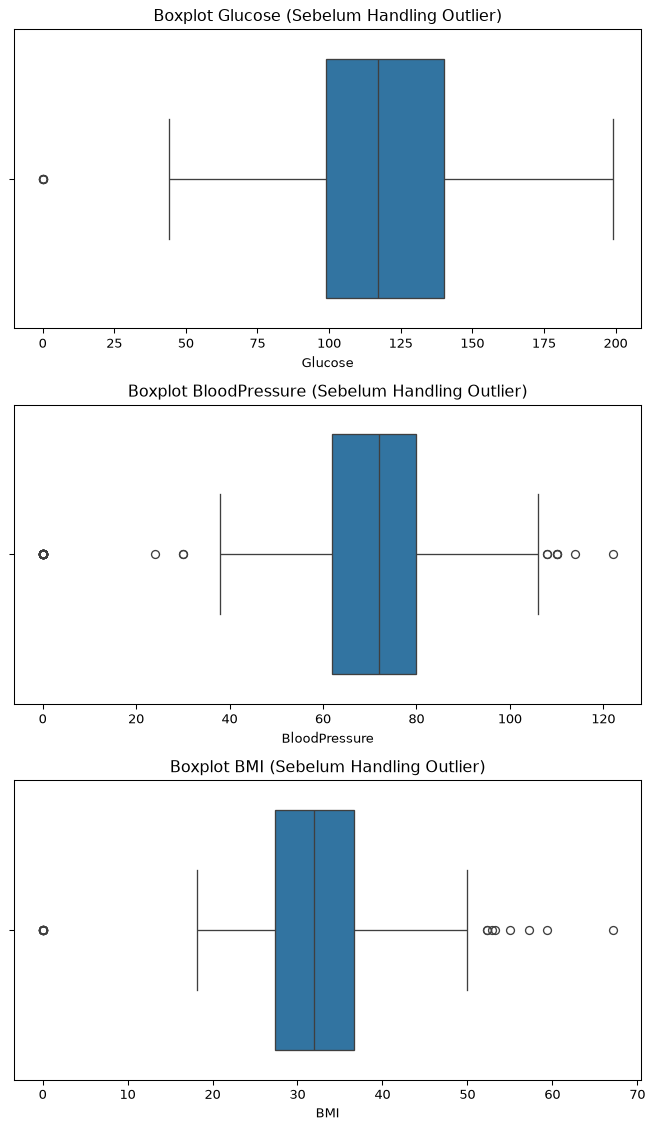

In [29]:
# 4.1 Deteksi outlier secara visual (sebelum dibersihkan)
selected_cols = ['Glucose', 'BloodPressure', 'BMI']

fig, axs = plt.subplots(len(selected_cols), 1, dpi=95, figsize=(7, 4 * len(selected_cols)))
for i, col in enumerate(selected_cols):
    sns.boxplot(x=diabetes[col], ax=axs[i])
    axs[i].set_title(f"Boxplot {col} (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

In [30]:
# 4.2 Menghapus outlier menggunakan IQR untuk ketiga kolom
def remove_outliers_sequentially(data, columns):
    df_cleaned = data.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

diabetes_clean = remove_outliers_sequentially(diabetes, selected_cols)

print(f"Jumlah baris sebelum : {len(diabetes)}")
print(f"Jumlah baris sesudah : {len(diabetes_clean)}")

Jumlah baris sebelum : 768
Jumlah baris sesudah : 709


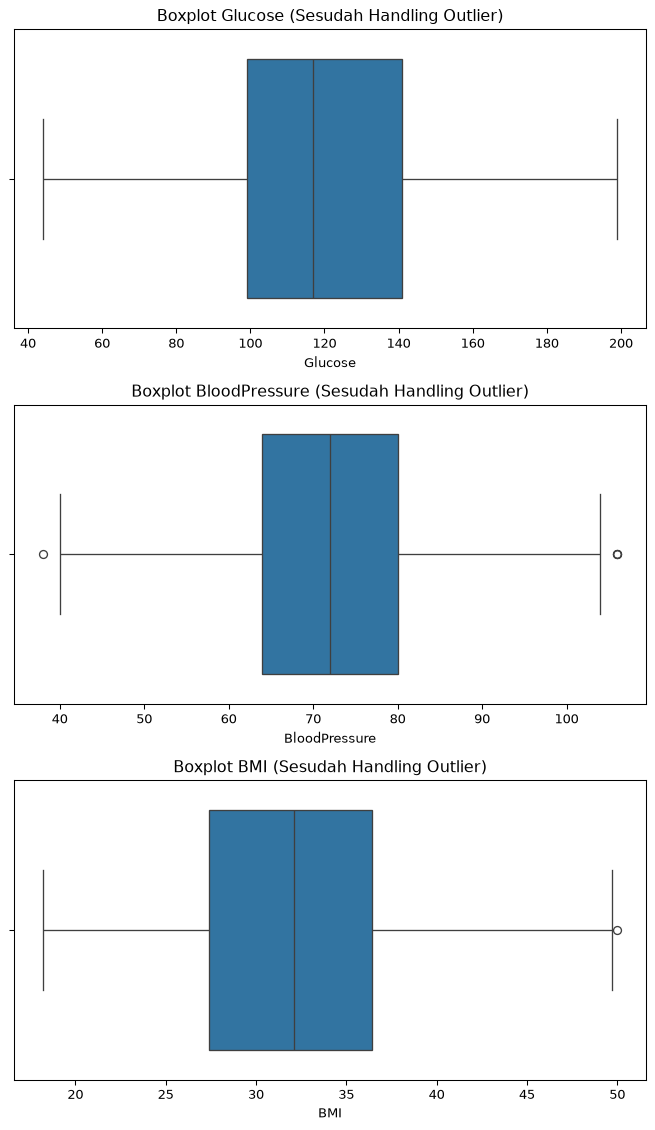

In [31]:
# 4.3 Deteksi outlier secara visual (sesudah dibersihkan)
fig, axs = plt.subplots(len(selected_cols), 1, dpi=95, figsize=(7, 4 * len(selected_cols)))
for i, col in enumerate(selected_cols):
    sns.boxplot(x=diabetes_clean[col], ax=axs[i])
    axs[i].set_title(f"Boxplot {col} (Sesudah Handling Outlier)")
plt.tight_layout()
plt.show()

**Catatan:** perbandingan boxplot sebelum dan sesudah menunjukkan bahwa titik-titik
di luar whisker (outlier) pada kolom Glucose, BloodPressure, dan BMI sudah tidak
muncul lagi setelah proses IQR filtering.

## Kesimpulan
Pada praktikum ini telah dilakukan dua teknik utama dalam data preprocessing:
1. **Handling Missing Value**, menggunakan `dropna()` dan `fillna()` (mean, median,
   mode, backward fill, forward fill), yang kemudian diterapkan pada dataset
   Titanic-Dataset.csv dengan hasil akhir tanpa missing value.
2. **Handling Outliers**, menggunakan metode Interquartile Range (IQR) yang
   divisualisasikan dengan boxplot, yang kemudian diterapkan pada dataset
   diabetes.csv pada kolom Glucose, BloodPressure, dan BMI.